In [ ]:
# %pip install scikit-learn


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.1 MB 16.4 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 15.9 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 14.6 MB/s  0:00:00
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   --- ------------------------------------ 3.7/37.3 MB 17.5 MB/s eta 0:00:02
   -------- ------------------------------- 7.6/37.3 MB 17.8 MB/s eta 0:00:02
   ----------- ---------------------------- 11.0/37.3 MB 17.3 MB/s eta 0:00:02
   --------------- ------------------------ 14.7/37.3 MB 17.0 MB/s eta 0:00:02
   -------------------- ------------------- 19.1/37.3 MB 17.6 MB/s eta 0:00:02
   ------------------------- -------------- 23.3/37.3 MB 17.9 MB/s eta 0:00:01
   --------------------------- ------------ 25.7/37.3 MB 17.2 MB/s eta 0:00:01
   ------------------------------ --------- 28.0/37.3 MB 16.0 MB/s eta 0:00:01
   


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df_partidos = pd.read_csv("datos.csv")
df_partidos.head()

,fecha_partido,equipo_local,equipo_visitante,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante,estadio
0,2023-01-01,Atlético Python,Cebollitas FC,2,0,54,46,12,6,Python Arena
1,2023-01-08,NumPy City,Atlético Python,1,5,60,40,12,3,Estadio ML
2,2023-01-15,Cebollitas FC,Data United,1,0,55,45,10,7,Python Arena
3,2023-01-22,Atlético Python,Data United,2,3,57,43,3,3,Campo Pandas
4,2023-01-29,Data United,Cebollitas FC,5,3,52,48,7,12,Estadio ML


In [12]:
# Aplicar normalización tiros de arco (aprox. 0-15 tiros)
scaler_nom = MinMaxScaler()

df_partidos["tiros_arco_local_norm"] = scaler_nom.fit_transform(df_partidos[["tiros_arco_local"]])
df_partidos["tiros_arco_visitante_norm"] = scaler_nom.fit_transform(df_partidos[["tiros_arco_visitante"]])

#Ver resultado
print(df_partidos[['tiros_arco_local', 'tiros_arco_local_norm']].head(6))
print(df_partidos[['tiros_arco_visitante', 'tiros_arco_visitante_norm']].head(6))

   tiros_arco_local  tiros_arco_local_norm
0                12               1.000000
1                12               1.000000
2                10               0.777778
3                 3               0.000000
4                 7               0.444444
5                 8               0.555556
   tiros_arco_visitante  tiros_arco_visitante_norm
0                     6                   0.333333
1                     3                   0.000000
2                     7                   0.444444
3                     3                   0.000000
4                    12                   1.000000
5                    11                   0.888889


In [15]:
# Aplicar estandarización a la posesión (%)
scaler_std = StandardScaler()

df_partidos['posesion_local_std'] = scaler_std.fit_transform(df_partidos[["posesion_local (%)"]])
df_partidos['posesion_visitante_std'] = scaler_std.fit_transform(df_partidos[["posesion_visitante (%)"]])

#Ver resultados
print(df_partidos[['posesion_local (%)', 'posesion_local_std']].head(6))
print(df_partidos[['posesion_visitante (%)', 'posesion_visitante_std']].head(6))

   posesion_local (%)  posesion_local_std
0                  54            0.624415
1                  60            1.623479
2                  55            0.790926
3                  57            1.123947
4                  52            0.291394
5                  60            1.623479
   posesion_visitante (%)  posesion_visitante_std
0                      46               -0.624415
1                      40               -1.623479
2                      45               -0.790926
3                      43               -1.123947
4                      48               -0.291394
5                      40               -1.623479


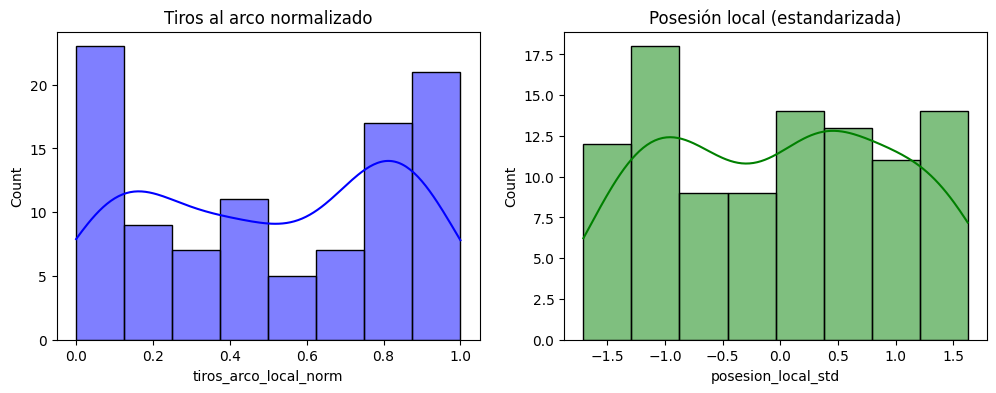

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

#Visualizar tiros al arco normalizados
sns.histplot(df_partidos['tiros_arco_local_norm'], ax=ax[0], kde=True, color='blue')
ax[0].set_title('Tiros al arco normalizado')

#Visualizar posesión estandarizada
sns.histplot(df_partidos['posesion_local_std'], ax=ax[1], kde=True, color='green')
ax[1].set_title('Posesión local (estandarizada)')

plt.show()